# surya ocr

In [4]:

!pip install transformers==4.44.2
!pip install surya-ocr==0.15.0

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 74.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 98.5 MB/s eta 0:00:00
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.21.4
    Uninstalling tokenizers-0.21.4:
      Successfully uninstalled tokenizers-0.21.4
  Attempting uninstall: transformers
    Found existing installation: transformers 4.52.2
    Uninstalling transformers-4.52.2:
      Successfully uninstalled transformers-4.52.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
surya-ocr 0.14.6 requires transformers<5.0.0,>=4.51.2, but you have transformers 4.44.2 which is incompatible.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.9/40.9 kB 4.1 MB/s eta 0:00:00
  Using cached tokenizers-0.21.4-cp39-abi3-manylin

In [6]:

from google.colab import files
from PIL import Image
from surya.foundation import FoundationPredictor
from surya.recognition import RecognitionPredictor
from surya.detection import DetectionPredictor

uploaded = files.upload()

nome_arquivo = list(uploaded.keys())[0]

img = Image.open(nome_arquivo)

foundation_predictor = FoundationPredictor()
reader = RecognitionPredictor(foundation_predictor)
detector = DetectionPredictor()

resultado = reader([img], det_predictor=detector)



Saving ocr-contas-enel.webp to ocr-contas-enel.webp


Recognizing Text: 100%|██████████| 127/127 [00:18<00:00,  6.83it/s]


In [10]:
for linha in resultado[0].text_lines:
    print(linha.text)

Eletropaulo Metropolitana Eletricidade de São Paulo S. A.
SEGUNDA VIA.
Av. das Nações Unidas, 14401 - Conjuntos 1 ao 4, 17<sup>e</sup> ao 23<sup>e</sup> andar, Torre B1<br>Vila Gertrudes, São Paulo/SP - Cep 04794-000
<math>\overline{1}</math>
CNPJ n 61.695 227/0001-93 - Inscrição Estadual. 133.122.090.117 | Regime Especial Proc. 1000635-686924/2005
Dados do Cliente/Unidade Consumidora
Dados da Conta
Histórico de Faturamento
VENCIMENTO<br>20 JUN 2022
TOTAL A PAGAR (RS)
Měs/Ano
kWh Dias
N° DA INSTALAÇÃO 000000000
N° DO CLIENTE 00000000
100,00
29
mai/22
30
CPF/CNPJ:00,000,000/0001-00
<b>INSC. EST:</b>
CONTA REFERENTE A MAI 2022
<math display="block">ab\,\rlap{\,/}22</math>
32
mar/22
28
🕙 Dados de Medição
fev/22
NOME DO CLIENTE
31
tan/22
01234567
Nº do medidor.
31
dez/21
Leitura anterior 28 ABR
100
R RUA1
29
nov/21
Leitura atual 27 MAI
<math display="block">31 \\</math>
100
out/21
CEP:00000-100 - CIDADE/UF
<math display="block">\mathsf{se}\psi21</math>
32
Próxima leitura 28 JUN
29
aqq/21
1

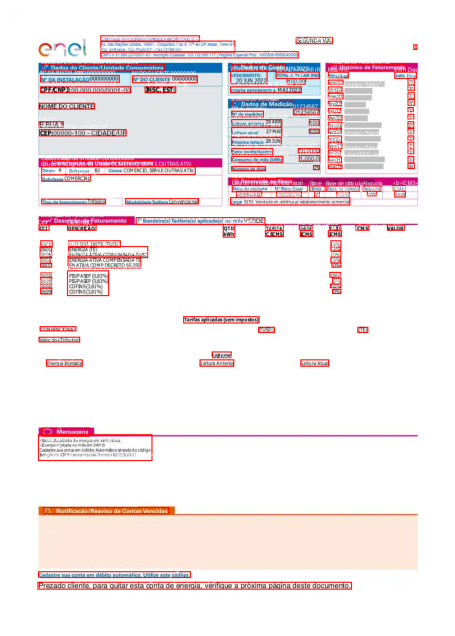

In [11]:

from PIL import ImageDraw
import matplotlib.pyplot as plt

img_pred = img.copy()
draw = ImageDraw.Draw(img_pred)

for linha in resultado[0].text_lines:
    x1, y1, x2, y2 = linha.bbox

    draw.rectangle([x1, y1, x2, y2], outline="red", width=2)
    draw.text((x1, y1 - 10), linha.text)

plt.figure(figsize=(14, 8))
plt.imshow(img_pred)
plt.axis("off")
plt.show()